# Ablation Landing-Probability Figures

Focused notebook for the ablation and no-contact landing-probability panels defined in `Seaborn_plot.py`.

## 1. Environment and plotting setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from contextlib import contextmanager
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "Seaborn_plot.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import Seaborn_plot as sp

DATA_FOLDER = Path(r"C:\Users\agrawal-admin\Desktop\LandingDataSummary")
OUTPUT_FOLDER = ROOT / "Figures" / "AblationFigure"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# These are the same defaults used by Seaborn_plot.py.
sp.FilterHighLatency = True
sp.Trial_num = 20
sp.Threshold = True
sp.trial_offset = 3
sp.latency_threshold = 0.71

@contextmanager
def working_directory(folder):
    previous = Path.cwd()
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    os.chdir(folder)
    try:
        yield
    finally:
        os.chdir(previous)

print(f"Python executable: {sys.executable}")
print(f"Data folder: {DATA_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")

Python executable: C:\Users\agrawal-admin\anaconda3\envs\DailyTask\python.exe
Data folder: C:\Users\agrawal-admin\Desktop\LandingDataSummary
Output folder: C:\Users\agrawal-admin\Desktop\New folder\Figures\AblationFigure


## 2. Configure the source datasets

In [2]:
ablation_specs = [
    ("WT-SL-T1-CxTr", DATA_FOLDER / "Necessity" / "T1RightIntact_CTF_LL_All.xlsx", 300, 1, 21),
    ("WT-SL-T2-TiTa", DATA_FOLDER / "Necessity" / "T2RightIntact_TTa_All.xlsx", 300, 1, 21),
    ("WT-SL-T2-CxTr", DATA_FOLDER / "Necessity" / "T2RightIntact_CTF_LL_All.xlsx", 300, 1, 20),
    ("WT-SL-T3-TiTa", DATA_FOLDER / "Necessity" / "T3RightIntact_TTa_All.xlsx", 300, 1, 17),
    ("WT-SL-T3-CxTr", DATA_FOLDER / "Necessity" / "T3RightIntact_CTF_LL_All.xlsx", 300, 1, 20),
]

no_contact_specs = [
    ("WT Abdomen", DATA_FOLDER / "CONTROL" / "WT-Abdomen-ALL.xlsx", 250, 1, 11),
    ("WT Ab T3CutOff", DATA_FOLDER / "CONTROL" / "WT-Ab-LegCutOff-ALL.xlsx", 250, 1, 10),
    ("No contact", DATA_FOLDER / "CONTROL" / "IntactFly_Control.xlsx", 300, 1, 10),
]

def load_lp_data(specs):
    datasets = []
    for label, path, fps, first_fly, last_fly in specs:
        if not path.exists():
            raise FileNotFoundError(path)
        lp_data, _ = sp.ReadLandingData(
            str(path), label, fps, first_fly, last_fly
        )
        datasets.append(lp_data)
    return datasets

for label, path, fps, first_fly, last_fly in ablation_specs + no_contact_specs:
    print(f"{label}: {path} | exists={path.exists()} | fps={fps} | flies={first_fly}-{last_fly}")

WT-SL-T1-CxTr: C:\Users\agrawal-admin\Desktop\LandingDataSummary\Necessity\T1RightIntact_CTF_LL_All.xlsx | exists=True | fps=300 | flies=1-21
WT-SL-T2-TiTa: C:\Users\agrawal-admin\Desktop\LandingDataSummary\Necessity\T2RightIntact_TTa_All.xlsx | exists=True | fps=300 | flies=1-21
WT-SL-T2-CxTr: C:\Users\agrawal-admin\Desktop\LandingDataSummary\Necessity\T2RightIntact_CTF_LL_All.xlsx | exists=True | fps=300 | flies=1-20
WT-SL-T3-TiTa: C:\Users\agrawal-admin\Desktop\LandingDataSummary\Necessity\T3RightIntact_TTa_All.xlsx | exists=True | fps=300 | flies=1-17
WT-SL-T3-CxTr: C:\Users\agrawal-admin\Desktop\LandingDataSummary\Necessity\T3RightIntact_CTF_LL_All.xlsx | exists=True | fps=300 | flies=1-20
WT Abdomen: C:\Users\agrawal-admin\Desktop\LandingDataSummary\CONTROL\WT-Abdomen-ALL.xlsx | exists=True | fps=250 | flies=1-11
WT Ab T3CutOff: C:\Users\agrawal-admin\Desktop\LandingDataSummary\CONTROL\WT-Ab-LegCutOff-ALL.xlsx | exists=True | fps=250 | flies=1-10
No contact: C:\Users\agrawal-admi

## 3. Ablation landing-probability panel

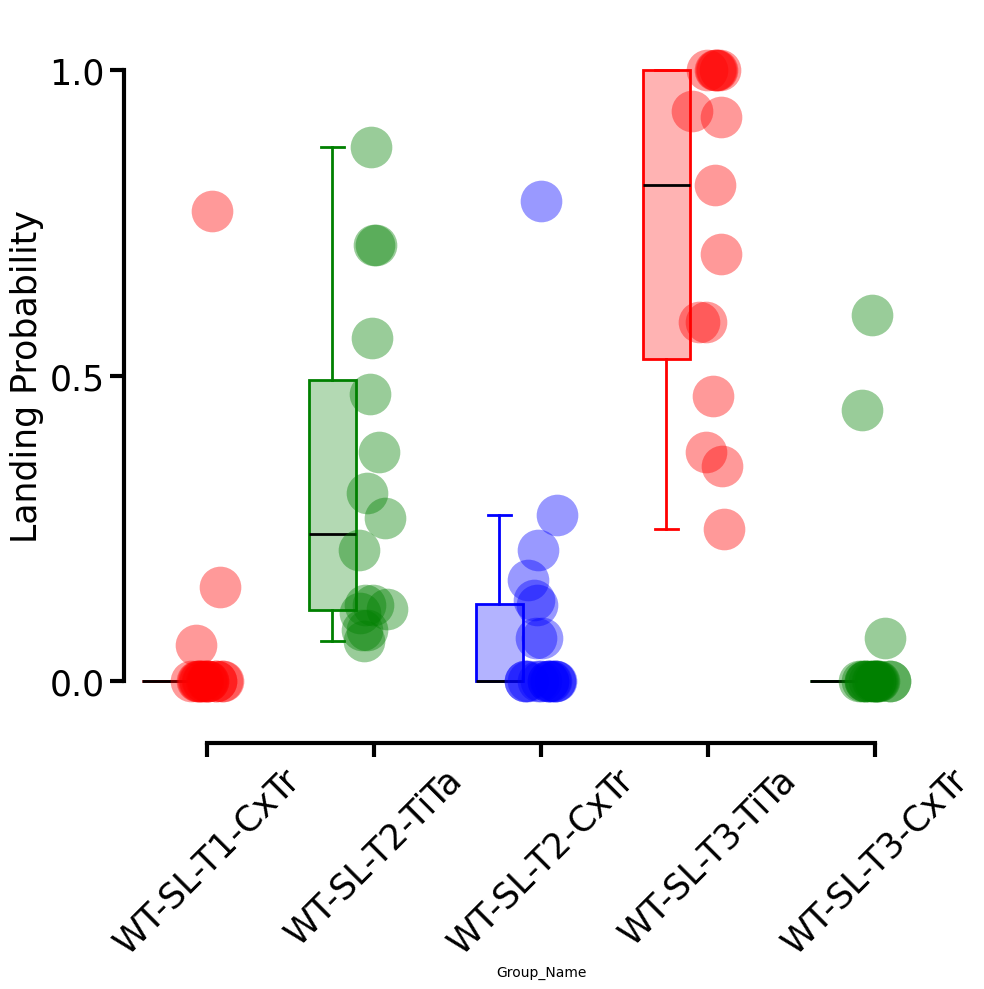

In [5]:
RUN_ABLATION_LP = True

if RUN_ABLATION_LP:
    ablation_data = load_lp_data(ablation_specs)
    with working_directory(OUTPUT_FOLDER):
        sp.LPAcrossFlies(
            Data_to_plot=ablation_data,
            file_name="Ablation",
            colors=["red", "green", "blue", "red", "green"],
            marker_styles=["o"] * len(ablation_data),
            box_width=0.28,
            box_softness=0.70,
        )

## 4. No-contact/control landing-probability panel

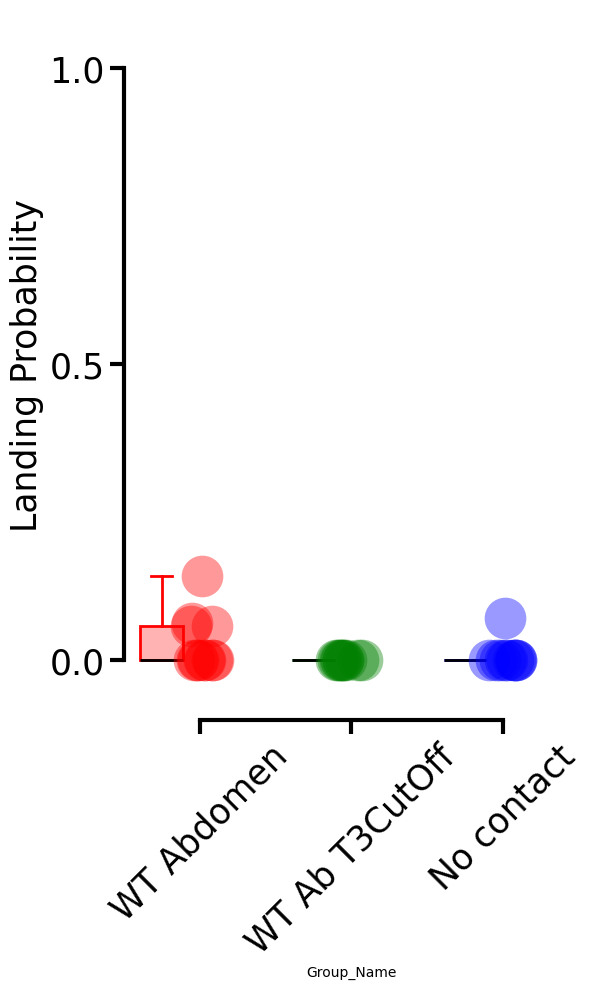

In [6]:
RUN_NO_CONTACT_LP = True

if RUN_NO_CONTACT_LP:
    no_contact_data = load_lp_data(no_contact_specs)
    with working_directory(OUTPUT_FOLDER):
        sp.LPAcrossFlies(
            Data_to_plot=no_contact_data,
            file_name="NoContact",
            colors=["red", "green", "blue"],
            marker_styles=["o"] * len(no_contact_data),
            box_width=0.28,
            box_softness=0.70,
        )

## Usage notes

1. Importing `Seaborn_plot` no longer executes its default figure workflow.
2. Run Sections 1 and 2 first.
3. Set only `RUN_ABLATION_LP` or `RUN_NO_CONTACT_LP` to `True`.
4. Figures and summary CSV files are saved under `Figures/AblationFigure`.
5. The boxes use softened versions of their corresponding point colors.